In [11]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from functions import haversine, get_walking_distance, get_district, \
                    remove_outliers, apply_jitter
warnings.filterwarnings('ignore')

# Cleaning Data

In [12]:
yerevan_historical = pd.read_excel('../database/raw_data/Yerevan historical.xlsx')

## filtering out duplicates in id 

as historical data keeps track of every price change and classifies \
a house sold based on if the listing for the house was removed. \
We only need data for the sold houses and filter out duplicates

In [14]:
# taking only sold apartments and houses
yerevan_historical = yerevan_historical[(yerevan_historical['backup_status'] == "sold") &
                                       ((yerevan_historical['rent_or_sale'] == "sale appartments") |
                                       (yerevan_historical['rent_or_sale'] == "sale houses"))]

yerevan_historical['date'] = pd.to_datetime(yerevan_historical['date'],
                                            format='%Y-%m-%d')

In [15]:
# dropping null values
houses_filt = yerevan_historical.dropna(subset=['price'])

In [16]:
# dropping duplicates and removing price change rows
filtered_df = houses_filt.groupby('id')['date'].idxmax() \
                         .apply(lambda x: houses_filt.loc[x]) \
                         .reset_index(drop=True)

# Generating new features for the data

An aspect of already improving on the data we have, was to add more features \
Thus in the below script you can find the following new columns generated for each of the houses:
- the district they belong to
- their closest metro station
- walking distance to that metro

This is done in order to understand if any of these spatial variables play a role in \
 affecting the price of the houses once we run the model

## District Regions

as our data has x, y coordinates setup we wrote a script to generate the corresponding district for each point \
this is later used for removing outliers corresponding to each region, creating more interesting visuals in arcgis \
and running the model with the context of the district for each house

### DO NOT!!! Run the script as it takes several hours for the data to be generated

In [ ]:
data = filtered_df.copy()

In [17]:
count = 0
yerevan_districts = pd.DataFrame(
    columns=['x', 'y', 'district']
)

below code gave http request errors sometimes (as a result of the quota for the package) so while, try, except \
were added to the code so that it continues to run the code again after the error

In [ ]:
while True:
    # noinspection PyBroadException
    try:
        # Loop through each row of the data and calculate the district for each row
        for i, row in data.iterrows():
            # Calculate the district for the current row
            district = get_district(row['x'], row['y'])
            count = count + 1
            data.drop(index=data.index[0], axis=0, inplace=True)
            # Append the current row to the new DataFrame
            yerevan_districts = yerevan_districts.append(
                {'x': row['x'], 'y': row['y'], 'district': district},
                ignore_index=True)
    except:
        # if there was an error, print a message and try again
        print("An error occurred. Retrying...")
        continue
    else:
        # if there was no error, break out of the loop and continue with the rest of the code
        break

An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...


In [ ]:
# converting armenian text for districts to english
armenian_to_english = {'Աջափնյակ': 'Achapnyak',
                       'Նոր Նորք': 'Nor_Nork',
                       'Արաբկիր': 'Arabkir',
                       'Կենտրոն': 'Kentron',
                       'Դավթաշեն': 'Davtashen',
                       'Էրեբունի': 'Erebuni',
                       'Շենգավիթ': 'Shengavit',
                       'Քանաքեռ-Զեյթուն': 'Qanaqer_Zeytun',
                       'Մալաթիա-Սեբաստիա': 'Malatia_Sebastia',
                       'Ավան': 'Avan',
                       'Նոր Նորքի 1-ին զանգված': 'Nor_Nork',
                       'Նոր Նորքի 2-րդ զանգված': 'Nor_Nork',
                       'Դավթաշեն գյուղ': 'Davtashen',
                       'Նորք Մարաշ': 'Norq_Marash',
                       'Գլենդել Հիլզ': 'Kentron',
                       'Նուբարաշեն': 'Nubarashen',
                       'Հաղթանակ': 'Malatia_Sebastia',
                       'Նոյ թաղամաս': 'Malatia_Sebastia',
                       'Մուշ թաղամաս': 'Malatia_Sebastia',
                       'Էկո քաղաք': 'Achapnyak'}

yerevan_districts['district'] = yerevan_districts['district'].replace(armenian_to_english)

In [ ]:
filtered_df["district"] = yerevan_districts["district"]

In [ ]:
# removing rows with no district
filtered_df = filtered_df.dropna(subset=['district']).reset_index(drop=True)
filtered_df_copy = filtered_df.copy()

In [5]:
# Save the results to a CSV file
filtered_df.to_csv("../database/yerevan_historical_clean/Yerevan_Historical_sales.csv", index=False)

## Metro Distance Calculation

we first use the haversine distance measure to calculate the angular distance between \
 each house and each metro on the surface of a sphere, \
to get the closest metro station for each house

Then we calculate the walking distance between each house and the closest metro, using the Maps API

In [ ]:
filtered_df = pd.read_csv("../database/yerevan_historical_clean/Yerevan_Historical_sales.csv")

# Metro Stations in Yerevan
stations = pd.DataFrame({
    'station_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'station_name': ['Barekamutyun', 'Baghramyan', 'Yeritasardakan', 'Republic Square', 'Zoravar Andranik',
                     'Sasuntsi Davit', 'Gortsaranain', 'Shengavit', 'Charbakh', 'Garegin Nzhdeh Square'],
    'x': [40.197446, 40.1918167, 40.1873081, 40.1785331, 40.1699272, 40.1552243, 40.1410611, 40.145224,
          40.1405941, 40.1504761],
    'y': [44.493467, 44.5038091, 44.5191743, 44.5134433, 44.5112603, 44.5058011, 44.4964173, 44.48483,
          44.4685333, 44.4816183]
})

#### calculating distance from every house to every metro station and taking shortest metro station

In [ ]:
# Loop through each house and station to find the shortest distance using Haversine
distances = []
station_ids = []
station_names = []
for house_idx, house in filtered_df.iterrows():
    shortest_distance = float('inf')
    nearest_station_name = ''
    for station_idx, station in stations.iterrows():
        distance = haversine(house['y'], house['x'], station['y'], station['x'])
        if distance < shortest_distance:
            shortest_distance = distance
            nearest_station_id = station['station_id']
            nearest_station_name = station['station_name']
            # no else needed for any of these variable as it will find a value that smaller than infinity
    station_ids.append(nearest_station_id)
    station_names.append(nearest_station_name)

# Add the new columns to the houses table
filtered_df['nearest_station_id'] = station_ids
filtered_df['nearest_station_name'] = station_names

In [ ]:
houses = filtered_df.copy()

#### we have the closest metro station using haversine distance, now we calculate the walking distance using Google Maps api

In [ ]:
# Loop through each house and station to find the distance in meters using Google Maps API
for i, house in houses.iterrows():
    distance = get_walking_distance(house['y'], house['x'],
                     stations['y'][house['nearest_station_id']-1],
                     stations['x'][house['nearest_station_id']-1])
    distances.append(distance)
    houses.drop(index=houses.index[0], axis=0, inplace=True)

filtered_df["walking_distance_to_metro(m)"] = distances

In [ ]:
# Save the results to a CSV file
filtered_df.to_csv("../database/yerevan_historical_clean/Yerevan_Historical_sales.csv", index=False)

### Square Meter and Price Per Meter issue

at some point during the scraping of the data around september an issue occurred that caused data regarding the price_per_meter \
column and the square_meters to disappear from a few rows interchangeably. Thus, we use the data gathered from each to compliment \
each other and gain back some of those missing values (around 3000 of them)

In [2]:
filtered_df = pd.read_csv("../database/yerevan_historical_clean/Yerevan_Historical_sales.csv")

In [3]:
filtered_df['square_meters'] = filtered_df['square_meters'].replace(0, None)
filtered_df['square_meters'] = filtered_df['square_meters'].astype(float)

for index, row in filtered_df.iterrows():
    if np.isnan(row['price_per_meter']):
        continue
    else:
        filtered_df.loc[index, 'square_meters'] = row['price'] / row['price_per_meter']
        
for index, row in filtered_df.iterrows():
    if np.isnan(row['square_meters']):
        continue
    else:
        filtered_df.loc[index, 'price_per_meter'] = row['price'] / row['square_meters']

## Outlier detection

### Box-Plot

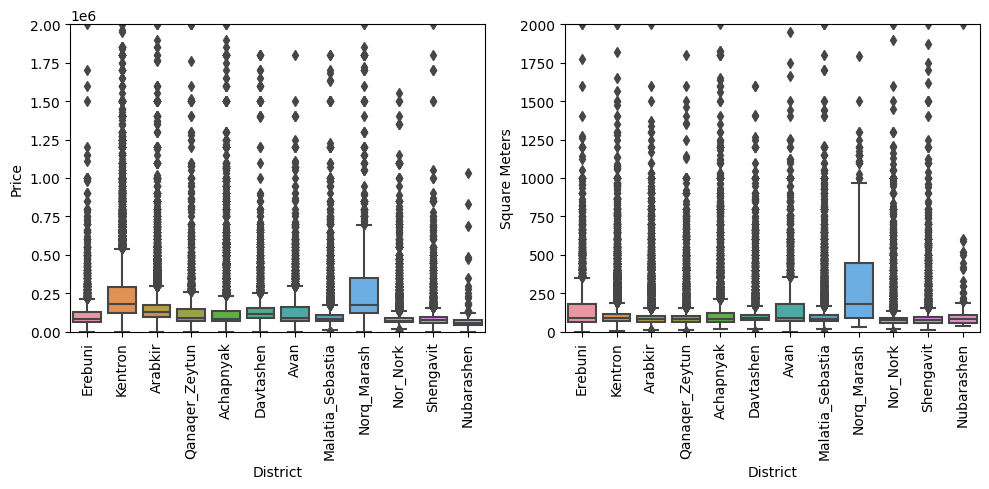

In [10]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

# Plot the price boxplot on the first subplot
sns.boxplot(x='district', y='price', data=filtered_df, ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
ax1.set_ylim(0, 2000000)
ax1.set_xlabel('District')
ax1.set_ylabel('Price')

# Plot the square_meters boxplot on the second subplot
sns.boxplot(x='district', y='square_meters', data=filtered_df, ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
ax2.set_ylim(0, 2000)
ax2.set_xlabel('District')
ax2.set_ylabel('Square Meters')

# Show the plot
plt.tight_layout()
plt.show()

### IQR

removing outlier values using IQR method described in the functions.py

In [28]:
filtered_df = remove_outliers(filtered_df, 'price', 5000)

District Achapnyak has 810 outliers
District Arabkir has 1391 outliers
District Avan has 402 outliers
District Davtashen has 455 outliers
District Erebuni has 392 outliers
District Kentron has 1750 outliers
District Malatia_Sebastia has 821 outliers
District Nor_Nork has 863 outliers
District Norq_Marash has 105 outliers
District Nubarashen has 23 outliers
District Qanaqer_Zeytun has 439 outliers
District Shengavit has 489 outliers


In [29]:
filtered_df = remove_outliers(filtered_df, 'square_meters', 40)

District Achapnyak has 714 outliers
District Arabkir has 1184 outliers
District Avan has 440 outliers
District Davtashen has 378 outliers
District Erebuni has 551 outliers
District Kentron has 2407 outliers
District Malatia_Sebastia has 727 outliers
District Nor_Nork has 522 outliers
District Norq_Marash has 38 outliers
District Nubarashen has 11 outliers
District Qanaqer_Zeytun has 713 outliers
District Shengavit has 902 outliers


## Spatial Jittering


the long and lat points are generated by mapping the address to the points corresponding on the map. \
As a lot of users don't define exact locations and have general addresses of where it is the same coordinate is matched for many locations

this causes issues when we try to run spatial forest based regression, as it won't identify the exact nearest neighbor to the house in question. \
Thus, we jitter each and every house very slightly by a random very small value


In [32]:
jitter_distance = 0.00001  # Adjust this value according to the desired jitter distance
filtered_df['latitude_jittered'] = filtered_df['y'].apply(lambda x: apply_jitter(x, jitter_distance))
filtered_df['longitude_jittered'] = filtered_df['x'].apply(lambda x: apply_jitter(x, jitter_distance))
grouped_data = filtered_df.groupby(['latitude_jittered', 'longitude_jittered']).size().reset_index(name='count')

sorted_grouped_data = grouped_data.sort_values('count', ascending=False)

most_frequent_coords = sorted_grouped_data.head()
print(most_frequent_coords)

       latitude_jittered  longitude_jittered  count
0              44.413052           40.170778      1
47999          44.515498           40.204269      1
48005          44.515498           40.204271      1
48004          44.515498           40.204273      1
48003          44.515498           40.204272      1


In [36]:
filtered_df.drop(columns=['OBJECTID', 'level_0', 'index', 'years_moths', 'nearest_station_id'], inplace=True)
filtered_df = filtered_df.rename(columns={'date': 'sold_date', 'nearest_station_name': 'closest_metro'})

In [60]:
filtered_df = filtered_df.reset_index(drop=True)

In [61]:
filtered_df.to_csv("../database/yerevan_historical_clean/sale_historical.csv", index=False) # without outliers